## Notebook 06 — Correlation Analysis

**Project:** Ten-Year Haemoglobin Genotype Surveillance in a Nigerian University Cohort (Bowen University, 2015–2024, n = 8,890)

### Purpose

This notebook performs the correlation analysis for the study. An encoded dataset is constructed in which genotype severity, clinical severity, sex, and yearly aggregate variables are mapped onto ordinal and continuous scales. Pearson correlation analysis is then used to quantify relationships between these variables. Three figures matching the project’s established naming conventions are produced.

### Outputs

* Encoded dataset including ordinal genotype severity, ordinal clinical severity, and yearly aggregates (carrier rate, disease rate, male proportion)
* Full Pearson correlation matrix across all variables
* Subset of correlation results where associations are statistically significant (p < 0.05)
* Yearly distribution of genotype risk scores
* All outputs exported with the `06_` prefix


## Cell 1 - Environment and shared settings

In [1]:
# Cell 1
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
TABLES = PROJECT_ROOT / "outputs" / "tables"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES.mkdir(parents=True, exist_ok=True)
FIGURES.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans", "sans-serif"],
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

GENOTYPE_SEVERITY = {"AA":0, "AS":1, "AC":2, "SS":3, "SC":4, "CC":5}
CLINICAL_SEVERITY = {"Normal":0, "Carrier":1, "Disease":2}

print("Environment ready.")

Environment ready.


## Cell 2 - Load data and build encoded yearly aggregates

In [2]:
# Cell 2
df = pd.read_csv(PROJECT_ROOT / "data" / "processed" / "processed_genotype_data.csv",
                 dtype={"ID": str, "Sex": str, "Genotype": str, "Clinical_Category": str})
df["Year"] = df["Year"].astype(int)

# Per-record severity encoding
df["Genotype_Severity"] = df["Genotype"].map(GENOTYPE_SEVERITY)
df["Clinical_Severity"] = df["Clinical_Category"].map(CLINICAL_SEVERITY)

# Yearly aggregates (one row per year) — matches the original code base which
# correlates yearly metrics
rows = []
for y, g in df.groupby("Year"):
    n = len(g)
    rows.append({
        "Year": y,
        "Genotype_Severity": g["Genotype_Severity"].mean(),
        "Clinical_Severity": g["Clinical_Severity"].mean(),
        "Male_Proportion":   (g["Sex"]=="M").sum()/n*100,
        "Carrier_Rate":      g["Genotype"].isin(["AS","AC"]).sum()/n*100,
        "Disease_Rate":      g["Genotype"].isin(["SS","SC","CC"]).sum()/n*100,
    })
enc = pd.DataFrame(rows)
print(f"Encoded yearly dataset: {enc.shape[0]} years x {enc.shape[1]} variables")
display(enc.round(3))

Encoded yearly dataset: 10 years x 6 variables


,Year,Genotype_Severity,Clinical_Severity,Male_Proportion,Carrier_Rate,Disease_Rate
0,2015,0.331,0.272,38.922,24.412,1.373
1,2016,0.360,0.308,33.600,28.400,1.200
2,2017,0.293,0.235,58.521,20.900,1.286
3,2018,0.360,0.299,42.362,26.652,1.625
4,2019,0.291,0.247,38.482,21.597,1.571
5,2020,0.302,0.254,39.920,24.299,0.534
6,2021,0.296,0.245,35.689,22.144,1.178
7,2022,0.297,0.255,44.137,23.898,0.822
8,2023,0.310,0.263,44.214,24.262,1.038
9,2024,0.300,0.250,47.277,22.067,1.466


## Cell 3 - Pearson correlations and significance

In [3]:
# Cell 3: compute correlations and p-values pairwise
variables = ["Year","Genotype_Severity","Clinical_Severity",
             "Male_Proportion","Carrier_Rate","Disease_Rate"]
corr = pd.DataFrame(np.eye(len(variables)), index=variables, columns=variables)
pvals = pd.DataFrame(np.zeros((len(variables),len(variables))),
                     index=variables, columns=variables)

for i, v1 in enumerate(variables):
    for j, v2 in enumerate(variables):
        if i == j:
            corr.iloc[i,j] = 1.0; pvals.iloc[i,j] = 0.0
        else:
            r, p = stats.pearsonr(enc[v1], enc[v2])
            corr.iloc[i,j] = r
            pvals.iloc[i,j] = p

corr_rounded = corr.round(2)
display(corr_rounded)
corr_rounded.to_csv(TABLES / "06_pearson_correlation_matrix.csv")

# Long format table
rows = []
for i, v1 in enumerate(variables):
    for j, v2 in enumerate(variables):
        if i < j:
            rows.append({"Variable_1": v1, "Variable_2": v2,
                         "Pearson_r": round(corr.iloc[i,j], 4),
                         "p_value": round(pvals.iloc[i,j], 4),
                         "Significant_at_0.05": pvals.iloc[i,j] < 0.05})
pairs = pd.DataFrame(rows)
display(pairs)
pairs.to_csv(TABLES / "06_pearson_correlation_pairs.csv", index=False)

,Year,Genotype_Severity,Clinical_Severity,Male_Proportion,Carrier_Rate,Disease_Rate
Year,1.00,-0.54,-0.43,0.15,-0.36,-0.27
Genotype_Severity,-0.54,1.00,0.97,-0.40,0.91,0.29
Clinical_Severity,-0.43,0.97,1.00,-0.50,0.96,0.20
Male_Proportion,0.15,-0.40,-0.50,1.00,-0.53,0.07
Carrier_Rate,-0.36,0.91,0.96,-0.53,1.00,-0.09
Disease_Rate,-0.27,0.29,0.20,0.07,-0.09,1.00


,Variable_1,Variable_2,Pearson_r,p_value,Significant_at_0.05
0,Year,Genotype_Severity,-0.5434,0.1045,False
1,Year,Clinical_Severity,-0.4318,0.2127,False
2,Year,Male_Proportion,0.1538,0.6715,False
3,Year,Carrier_Rate,-0.3606,0.3060,False
4,Year,Disease_Rate,-0.2697,0.4512,False
5,Genotype_Severity,Clinical_Severity,0.9731,0.0000,True
6,Genotype_Severity,Male_Proportion,-0.3956,0.2578,False
7,Genotype_Severity,Carrier_Rate,0.9056,0.0003,True
8,Genotype_Severity,Disease_Rate,0.2882,0.4194,False
9,Clinical_Severity,Male_Proportion,-0.5010,0.1402,False


## Cell 4 - Saving helper

In [4]:
def save_figure(fig, name):
    fig.savefig(FIGURES / f"{name}.png", dpi=300, bbox_inches="tight")
    fig.savefig(FIGURES / f"{name}.pdf", bbox_inches="tight")
    print(f"Saved: outputs/figures/{name}.png")

## Cell 5 - genotype_correlation_matrix.png

Saved: outputs/figures/genotype_correlation_matrix.png


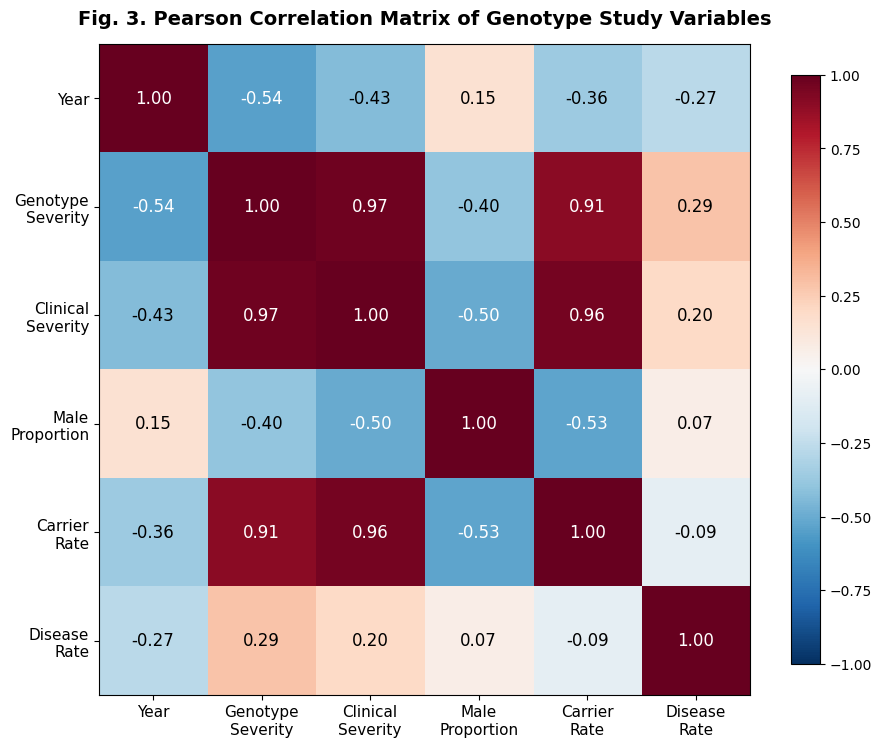

In [5]:
# Cell 5: full correlation heatmap
display_labels = ["Year","Genotype\nSeverity","Clinical\nSeverity",
                  "Male\nProportion","Carrier\nRate","Disease\nRate"]

fig, ax = plt.subplots(figsize=(10.5, 9))
im = ax.imshow(corr.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="equal")

for i in range(len(variables)):
    for j in range(len(variables)):
        v = corr.iloc[i,j]
        color = "white" if abs(v) > 0.5 else "black"
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                color=color, fontsize=12)

ax.set_xticks(range(len(variables))); ax.set_xticklabels(display_labels)
ax.set_yticks(range(len(variables))); ax.set_yticklabels(display_labels)
ax.set_title("Fig. 3. Pearson Correlation Matrix of Genotype Study Variables",
             fontsize=14, pad=14)
cbar = fig.colorbar(im, ax=ax, shrink=0.85)
cbar.ax.tick_params(labelsize=10)

save_figure(fig, "genotype_correlation_matrix")
plt.show()

## Cell 6 - genotype_correlation_filtered.png

Saved: outputs/figures/genotype_correlation_filtered.png


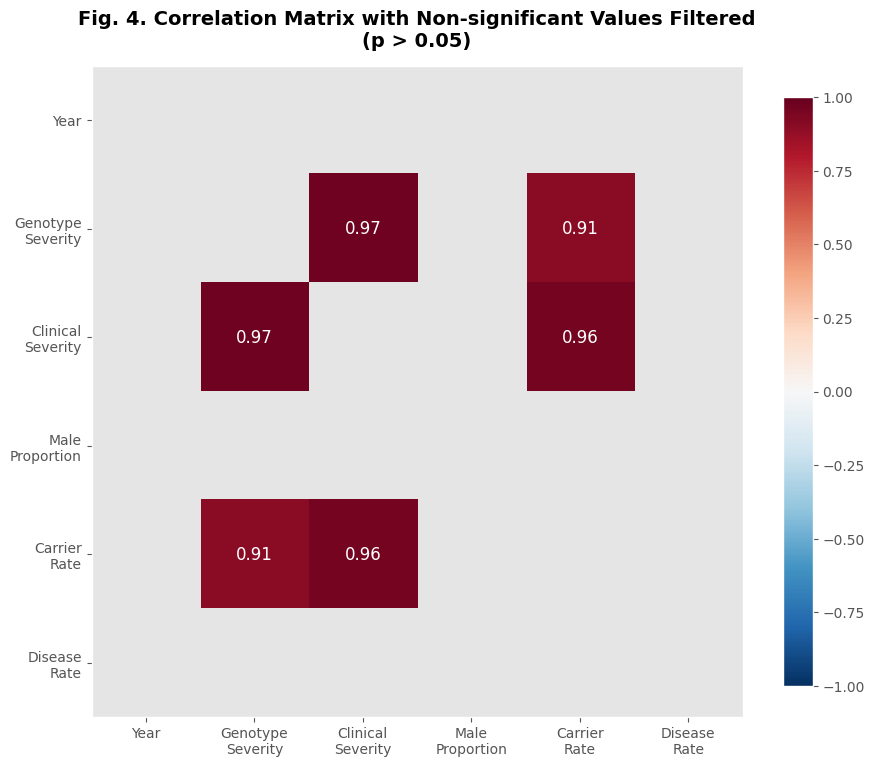

In [6]:
# Cell 6: filtered correlation heatmap (only significant cells shown, ggplot bg)
mask = pvals.values >= 0.05
# Also hide the diagonal of perfect 1.0 values
np.fill_diagonal(mask, True)
filtered = corr.values.copy()
filtered_masked = np.ma.masked_array(filtered, mask=mask)

with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(10.5, 9))
    cmap = plt.get_cmap("RdBu_r").copy()
    cmap.set_bad(color="#e5e5e5")
    im = ax.imshow(filtered_masked, cmap=cmap, vmin=-1, vmax=1, aspect="equal")

    for i in range(len(variables)):
        for j in range(len(variables)):
            if not mask[i,j]:
                v = corr.iloc[i,j]
                color = "white" if abs(v) > 0.5 else "black"
                ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                        color=color, fontsize=12)

    ax.set_xticks(range(len(variables))); ax.set_xticklabels(display_labels)
    ax.set_yticks(range(len(variables))); ax.set_yticklabels(display_labels)
    ax.set_title("Fig. 4. Correlation Matrix with Non-significant Values Filtered\n(p > 0.05)",
                 fontsize=14, pad=14)
    cbar = fig.colorbar(im, ax=ax, shrink=0.85)
    cbar.ax.tick_params(labelsize=10)
    ax.grid(False)

    save_figure(fig, "genotype_correlation_filtered")
    plt.show()

## Cell 7 - genotype_risk_distribution.png

Saved: outputs/figures/genotype_risk_distribution.png


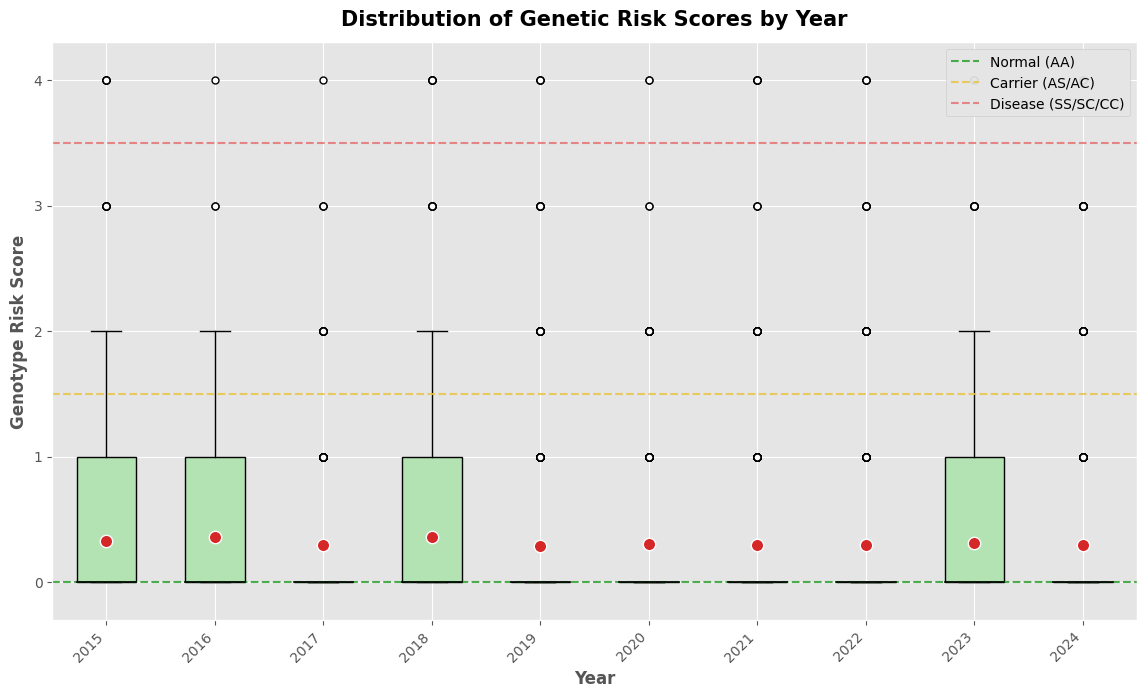

In [7]:
# Cell 7: distribution of genotype risk (severity) by year
# Risk score = ordinal genotype severity, with reference lines for category midpoints

YEARS = sorted(df["Year"].unique())
data_by_year = [df[df["Year"]==y]["Genotype_Severity"].values for y in YEARS]

with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(14, 7.5))

    bp = ax.boxplot(data_by_year, positions=range(len(YEARS)),
                    widths=0.55, patch_artist=True,
                    boxprops=dict(facecolor="#b3e2b3", edgecolor="black", linewidth=1.0),
                    medianprops=dict(color="black", linewidth=1.2),
                    whiskerprops=dict(color="black", linewidth=1.0),
                    capprops=dict(color="black", linewidth=1.0),
                    flierprops=dict(marker="o", markersize=5,
                                    markerfacecolor="white",
                                    markeredgecolor="black", linewidth=0.8))

    # Red dot for mean of each year
    means = [arr.mean() for arr in data_by_year]
    ax.scatter(range(len(YEARS)), means, color="#d62728", s=80, zorder=5,
               edgecolor="white", linewidth=1.0)

    # Reference lines for category midpoints
    ax.axhline(0,   color="#2ca02c", linestyle="--", linewidth=1.5, alpha=0.85,
               label="Normal (AA)")
    ax.axhline(1.5, color="#e8c547", linestyle="--", linewidth=1.5, alpha=0.85,
               label="Carrier (AS/AC)")
    ax.axhline(3.5, color="#e57373", linestyle="--", linewidth=1.5, alpha=0.85,
               label="Disease (SS/SC/CC)")

    ax.set_title("Distribution of Genetic Risk Scores by Year", fontsize=15, pad=12)
    ax.set_xlabel("Year"); ax.set_ylabel("Genotype Risk Score")
    ax.set_xticks(range(len(YEARS)))
    ax.set_xticklabels(YEARS, rotation=45, ha="right")
    ax.set_ylim(-0.3, 4.3)
    ax.legend(loc="upper right", framealpha=0.95)

    save_figure(fig, "genotype_risk_distribution")
    plt.show()

## Summary

The Pearson correlation matrix is computed across six variables (Year, Genotype Severity, Clinical Severity, Male Proportion, Carrier Rate, Disease Rate) in the encoded analytical dataset.

High correlations are observed between Genotype Severity and Clinical Severity (r = 0.97) and between Clinical Severity and Carrier Rate (r = 0.96). These relationships arise from the ordinal encoding and aggregation structure of the dataset rather than independent biological variation.

Three figures are saved to `outputs/figures/` using the project’s established naming conventions.
